In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive"

'archive (1).zip'  'Colab Notebooks'  'Fruits Classification'


In [3]:
!unzip "/content/drive/MyDrive/archive (1).zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/Fruits Classification/train/Grape/Grape (1950).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1952).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1953).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1955).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1956).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1957).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1958).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1959).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (196).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1960).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1961).jpeg  
  inflating: /content/Fruits Classification/train/Grape/Grape (1962).jpeg  
  inflating: /content/Fruits Classific

In [4]:
!ls "/content"

 drive	'Fruits Classification'   sample_data


In [6]:
import os

train_dir = "/content/Fruits Classification/train"
valid_dir = "/content/Fruits Classification/valid"
test_dir = "/content/Fruits Classification/test"


print("train classes:",os.listdir(train_dir))
print("validation classes:",os.listdir(valid_dir))
print("test classes:",os.listdir(test_dir))

train classes: ['Mango', 'Grape', 'Apple', 'Banana', 'Strawberry']
validation classes: ['Mango', 'Grape', 'Apple', 'Banana', 'Strawberry']
test classes: ['Mango', 'Grape', 'Apple', 'Banana', 'Strawberry']


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:

train_dir="/content/Fruits Classification/train"
val_dir = "/content/Fruits Classification/valid"
test_dir = "/content/Fruits Classification/test"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


In [10]:
model = Sequential()


model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())


model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(5, activation='softmax'))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,213 (24.87 MB)

 Trainable params: 6,517,765 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "fruit_classifier.keras",
    save_best_only=True
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - accuracy: 0.3916 - loss: 1.3967 - val_accuracy: 0.2550 - val_loss: 2.7571
Epoch 2/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 0.4155 - loss: 1.3395 - val_accuracy: 0.4200 - val_loss: 1.8191
Epoch 3/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accuracy: 0.4506 - loss: 1.2821 - val_accuracy: 0.4450 - val_loss: 1.2283
Epoch 4/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.4701 - loss: 1.2430 - val_accuracy: 0.5200 - val_loss: 1.0744
Epoch 5/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 577s 2s/step - accuracy: 0.4974 - loss: 1.1974 - val_accuracy: 0.5200 - val_loss: 1.0682
Epoch 6/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.5154 - loss: 1.1732 - val_accuracy: 0.4500 - val_loss: 1.3280
Epoch 7/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.5362 - loss: 1.1499 - val_accuracy: 0.5900 - val_loss: 1.0355
Epoch 8/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.5371 - loss: 1.1425 - val_accu

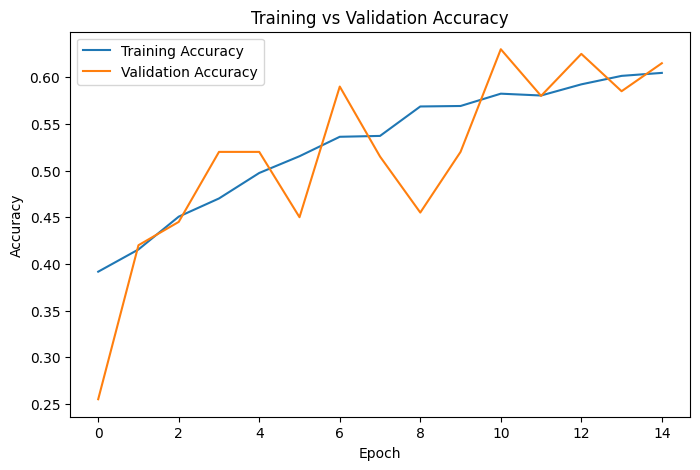

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

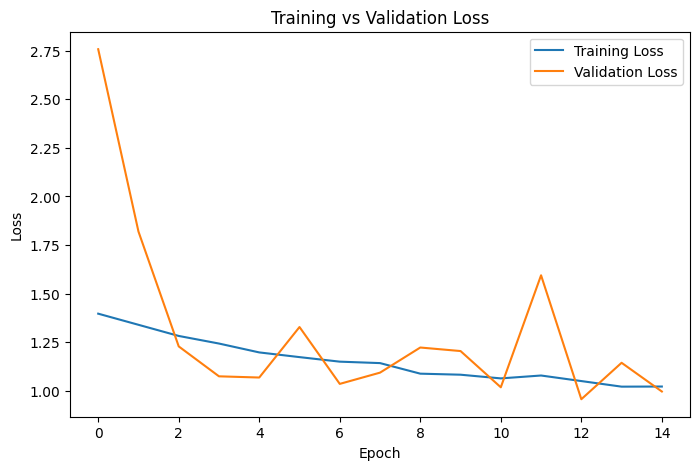

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()